# Imports & configuration

In [83]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, kendalltau
import matplotlib.pyplot as plt

np.random.seed(42)

EXCEL_PATH = "North-Western.xlsx"
xls = pd.ExcelFile(EXCEL_PATH)

## Load ORI (Risk Weights)

In [84]:
# Read the Risk Weights sheet
risk_df = pd.read_excel(xls, sheet_name="Risk Weights")
# Drop undefined rows
risk_df = risk_df.dropna(subset=["Objective", "Weight w (normalized)"])
# Build weights dictionary
weights = {row["Objective"]: row["Weight w (normalized)"] for _, row in risk_df.iterrows()}
# Keep only specified objectives and normalize
weights = {k: weights[k] for k in ["Av", "Phy", "AM", "CIA"]}
total = sum(weights.values())
weights = {k: v / total for k, v in weights.items()}
print("Objective weights (ORI):", weights)

Objective weights (ORI): {'Av': 0.3780718336483932, 'Phy': 0.2646502835538752, 'AM': 0.19848771266540643, 'CIA': 0.15879017013232513}


## Load Topic Effectiveness (r, u, v)

In [85]:
topic_df = pd.read_excel(xls, sheet_name="Topic Effectiveness", header=1)
# Show head of the table
topic_df.head()

,Topic,r_Av,r_Phy,r_AM,r_CIA,v_j,u_Av,u_Phy,u_AM,u_CIA,...,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,What does β represent?,Unnamed: 27,Unnamed: 28
0,Network Security,0.8,0.2,0.3,0.9,0.80,0.9,0.1,0.4,0.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Identity and Access Management (IAM),0.6,0.2,0.9,0.8,0.85,0.6,0.4,0.9,0.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,It controls the relative importance of:,NaN,NaN
2,Cryptography,0.4,0.1,0.4,0.9,0.40,0.3,0.1,0.5,0.95,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Structural relevance (rijr_{ij}rij​): how well...,NaN,NaN
3,Security Operations,0.9,0.3,0.8,0.6,0.75,0.8,0.4,0.8,0.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Vulnerability-driven term (vjuijv_j u_{ij}vj​u...,NaN,NaN
4,Security Awareness & Training,0.5,0.2,0.6,0.5,0.90,0.6,0.3,0.7,0.60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Compute η matrix (topic × objective)

In [86]:
BETA = 0.7

def compute_eta_matrix(topic_df, beta):
    r_cols = ["r_Av", "r_Phy", "r_AM", "r_CIA"]
    u_cols = ["u_Av", "u_Phy", "u_AM", "u_CIA"]

    df = topic_df.set_index("Topic").copy()
    df[r_cols + u_cols + ["v_j"]] = df[r_cols + u_cols + ["v_j"]].astype(float)
    eta = pd.DataFrame(index=df.index)
    for r_col, u_col in zip(r_cols, u_cols):
        obj = r_col.replace("r_", "")
        eta[obj] = beta * df[r_col] + (1 - beta) * df["v_j"] * df[u_col]
    return eta

eta_matrix = compute_eta_matrix(topic_df, BETA)
# Align with r matrix indices
r_matrix = topic_df.set_index("Topic")[["r_Av", "r_Phy", "r_AM", "r_CIA"]]
r_matrix = r_matrix.rename(columns={"r_Av":"Av", "r_Phy":"Phy", "r_AM":"AM", "r_CIA":"CIA"})
r_matrix = r_matrix[~r_matrix.index.isna()]
r_matrix = r_matrix.loc[~r_matrix.index.duplicated()]
eta_matrix = eta_matrix.loc[r_matrix.index]
print(eta_matrix.head())

                                         Av    Phy      AM     CIA
Topic                                                             
Network Security                      0.776  0.164  0.3060  0.7980
Identity and Access Management (IAM)  0.573  0.242  0.8595  0.7895
Cryptography                          0.316  0.082  0.3400  0.7440
Security Operations                   0.810  0.300  0.7400  0.5775
Security Awareness & Training         0.512  0.221  0.6090  0.5120


## Load Interdependency matrix D and α

In [87]:
# Read raw Interdependency sheet
D_raw = pd.read_excel(xls, sheet_name="Interdependency", header=None)
# Extract numeric D block (10x10) from rows 1-10, cols 1-10
D = D_raw.iloc[1:11, 1:11].astype(float).values
# Extract alpha from the sheet
ALPHA = float(D_raw.loc[D_raw.iloc[:, 0] == "Alpha"].iloc[0, 1])
I = np.eye(D.shape[0])
M = I + ALPHA * D
print("Alpha:", ALPHA)
print("D shape:", D.shape)

Alpha: 0.2
D shape: (10, 10)


## Compute η′ (eta prime)

In [88]:
def compute_eta_prime(eta_matrix, M):
    eta_p = M.dot(eta_matrix.values)
    return pd.DataFrame(eta_p, index=eta_matrix.index, columns=eta_matrix.columns)

eta_prime = compute_eta_prime(eta_matrix, M)
eta_prime.head()

,Av,Phy,AM,CIA
Topic,,,,
Network Security,0.949548,0.266760,0.449970,0.929490
Identity and Access Management (IAM),0.748300,0.398040,1.040060,0.959985
Cryptography,0.373462,0.107448,0.399523,0.801848
Security Operations,0.946580,0.361790,0.908590,0.717780
Security Awareness & Training,0.635440,0.315280,0.747670,0.631785


## Compute final scores & baseline ranking

In [89]:
def compute_scores(weights, eta_prime):
    w = pd.Series(weights, dtype=float)
    scores = eta_prime.mul(w, axis=1).sum(axis=1)
    scores.name = "Score"
    return scores

baseline_scores = compute_scores(weights, eta_prime)
baseline_ranks = baseline_scores.rank(ascending=False, method="average")
baseline_scores.sort_values(ascending=False), baseline_ranks.sort_values()

(Topic
 Critical Infrastructure Security        0.830498
 Security Operations                     0.747943
 Identity and Access Management (IAM)    0.747128
 Supply Chain Security                   0.711088
 Network Security                        0.666503
 Risk analysis                           0.612607
 Physical Security                       0.574052
 Security Awareness & Training           0.572405
 Cyber Threat Intelligence               0.539539
 Cryptography                            0.376258
 Name: Score, dtype: float64,
 Topic
 Critical Infrastructure Security         1.0
 Security Operations                      2.0
 Identity and Access Management (IAM)     3.0
 Supply Chain Security                    4.0
 Network Security                         5.0
 Risk analysis                            6.0
 Physical Security                        7.0
 Security Awareness & Training            8.0
 Cyber Threat Intelligence                9.0
 Cryptography                            1

## Monte Carlo simulation

In [90]:
N_SIM = 10_000
UNCERTAINTY = 0.10
spearman_vals, kendall_vals, flip_rates = [], [], []
baseline_order = baseline_ranks.sort_values().index.tolist()
pairs = [(i, j) for i in range(len(baseline_order)) for j in range(i+1, len(baseline_order))]
# Initialize once before Monte Carlo loop
rank_change_counts = {topic: 0 for topic in baseline_ranks.index}
score_history = {topic: [] for topic in baseline_scores.index}




for _ in range(N_SIM):
    # Perturb ORI
    perturbed_weights = {k: v * (1 + np.random.uniform(-UNCERTAINTY, UNCERTAINTY)) for k, v in weights.items()}
    total = sum(perturbed_weights.values())
    perturbed_weights = {k: v / total for k, v in perturbed_weights.items()}
    # Perturb r, u, v
    perturbed_topic_df = topic_df.copy()
    for col in ["r_Av","r_Phy","r_AM","r_CIA","u_Av","u_Phy","u_AM","u_CIA","v_j"]:
        perturbed_topic_df[col] *= (1 + np.random.uniform(-UNCERTAINTY, UNCERTAINTY))
        perturbed_topic_df[col] = perturbed_topic_df[col].clip(0, 1)
    eta_mc = compute_eta_matrix(perturbed_topic_df, BETA)
    eta_mc = eta_mc.loc[eta_matrix.index]
    eta_prime_mc = compute_eta_prime(eta_mc, M)
    new_scores = compute_scores(perturbed_weights, eta_prime_mc)
    new_ranks = new_scores.rank(ascending=False)
    rho, _ = spearmanr(baseline_ranks, new_ranks)
    tau, _ = kendalltau(baseline_ranks, new_ranks)
    spearman_vals.append(rho)
    kendall_vals.append(tau)
    new_order = new_ranks.sort_values().index.tolist()

    # Track rank changes (topic-level)
    for topic in baseline_ranks.index:
        if new_ranks.loc[topic] != baseline_ranks.loc[topic]:
            rank_change_counts[topic] += 1

    # Track score dispersion
    for topic in new_scores.index:
        score_history[topic].append(new_scores.loc[topic])



    flips = sum(
        (new_order.index(baseline_order[i]) - new_order.index(baseline_order[j])) * (i - j) < 0
        for i, j in pairs
    )
    flip_rates.append(flips / len(pairs))


rank_change_freq = {
    topic: count / N_SIM
    for topic, count in rank_change_counts.items()
}

score_std = {
    topic: np.std(values)
    for topic, values in score_history.items()
}



## Monte Carlo summary statistics

In [91]:
print("Spearman mean:", np.mean(spearman_vals))
print("Spearman min :", np.min(spearman_vals))
print("Kendall mean :", np.mean(kendall_vals))
print("Kendall min  :", np.min(kendall_vals))
print("Flip rate avg:", np.mean(flip_rates))

print("\nRank change frequency per topic:")
print("-" * 40)


Spearman mean: 0.9861430303030304
Spearman min : 0.9393939393939393
Kendall mean : 0.9517200000000001
Kendall min  : 0.8666666666666666
Flip rate avg: 0.024139999999999998

Rank change frequency per topic:
----------------------------------------


In [92]:
for topic, freq in sorted(
    rank_change_freq.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{topic:40s} : {freq:.3f}")

print("\nScore dispersion per topic (standard deviation):")
print("-" * 40)

for topic, std in sorted(
    score_std.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{topic:40s} : {std:.5f}")

Physical Security                        : 0.607
Security Awareness & Training            : 0.605
Identity and Access Management (IAM)     : 0.422
Security Operations                      : 0.422
Cyber Threat Intelligence                : 0.054
Risk analysis                            : 0.005
Network Security                         : 0.000
Cryptography                             : 0.000
Critical Infrastructure Security         : 0.000
Supply Chain Security                    : 0.000

Score dispersion per topic (standard deviation):
----------------------------------------
Critical Infrastructure Security         : 0.02380
Security Operations                      : 0.02333
Network Security                         : 0.02236
Identity and Access Management (IAM)     : 0.02192
Supply Chain Security                    : 0.02065
Risk analysis                            : 0.01858
Security Awareness & Training            : 0.01723
Cyber Threat Intelligence                : 0.01690
Physical Se

## Spearman histogram

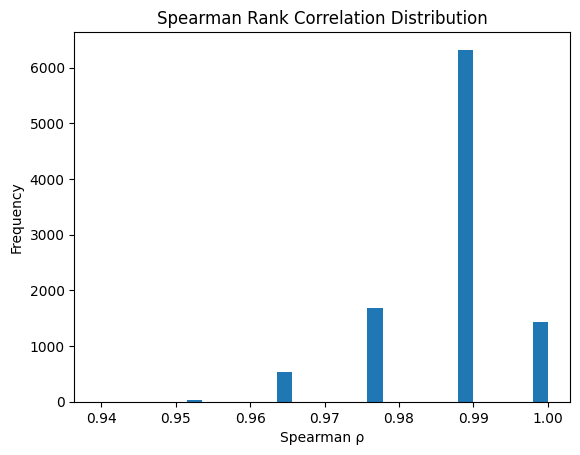

In [93]:
plt.hist(spearman_vals, bins=30)
plt.title("Spearman Rank Correlation Distribution")
plt.xlabel("Spearman ρ")
plt.ylabel("Frequency")
plt.show()

## Kendall histogram

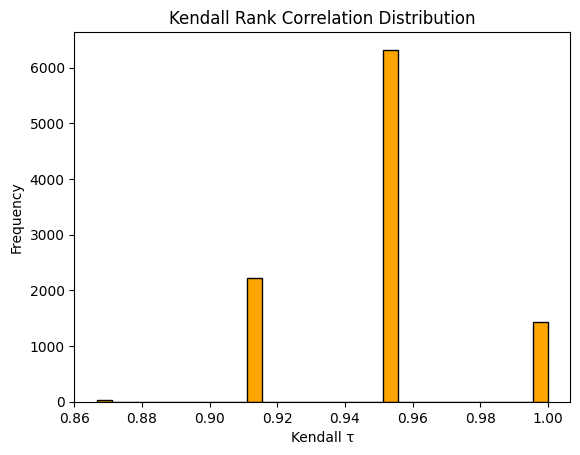

In [94]:
plt.hist(kendall_vals, bins=30, color="orange", edgecolor="black")
plt.title("Kendall Rank Correlation Distribution")
plt.xlabel("Kendall τ")
plt.ylabel("Frequency")
plt.show()


## Flip-rate histogram

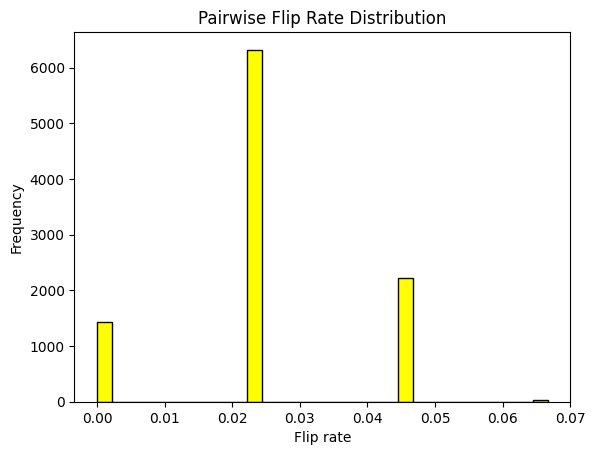

In [95]:
plt.hist(flip_rates, bins=30, color="yellow", edgecolor="black")
plt.title("Pairwise Flip Rate Distribution")
plt.xlabel("Flip rate")
plt.ylabel("Frequency")
plt.show()


## Stress tests

In [96]:
stress_results = []

baseline_order = baseline_ranks.sort_values().index.tolist()
pairs = [(i, j) for i in range(len(baseline_order)) for j in range(i+1, len(baseline_order))]

for obj in weights:
    for sign in [-1, 1]:
        stressed_weights = weights.copy()
        stressed_weights[obj] *= (1 + sign * UNCERTAINTY)

        total = sum(stressed_weights.values())
        stressed_weights = {k: v / total for k, v in stressed_weights.items()}

        stressed_scores = compute_scores(stressed_weights, eta_prime)
        stressed_ranks = stressed_scores.rank(ascending=False)

        # Correlations
        rho, _ = spearmanr(baseline_ranks, stressed_ranks)
        tau, _ = kendalltau(baseline_ranks, stressed_ranks)

        # Flip rate
        stressed_order = stressed_ranks.sort_values().index.tolist()
        flips = sum(
            (stressed_order.index(baseline_order[i]) -
             stressed_order.index(baseline_order[j])) * (i - j) < 0
            for i, j in pairs
        )
        flip_rate = flips / len(pairs)

        stress_results.append({
            "Scenario": f"{obj} {'+' if sign>0 else '-'}{int(UNCERTAINTY*100)}%",
            "Spearman": rho,
            "Kendall": tau,
            "FlipRate": flip_rate
        })

stress_df = pd.DataFrame(stress_results)
stress_df


,Scenario,Spearman,Kendall,FlipRate
0,Av -10%,0.987879,0.955556,0.022222
1,Av +10%,0.987879,0.955556,0.022222
2,Phy -10%,0.987879,0.955556,0.022222
3,Phy +10%,0.987879,0.955556,0.022222
4,AM -10%,1.000000,1.000000,0.000000
5,AM +10%,0.987879,0.955556,0.022222
6,CIA -10%,1.000000,1.000000,0.000000
7,CIA +10%,0.975758,0.911111,0.044444


## Rank Change Frequency per Topic

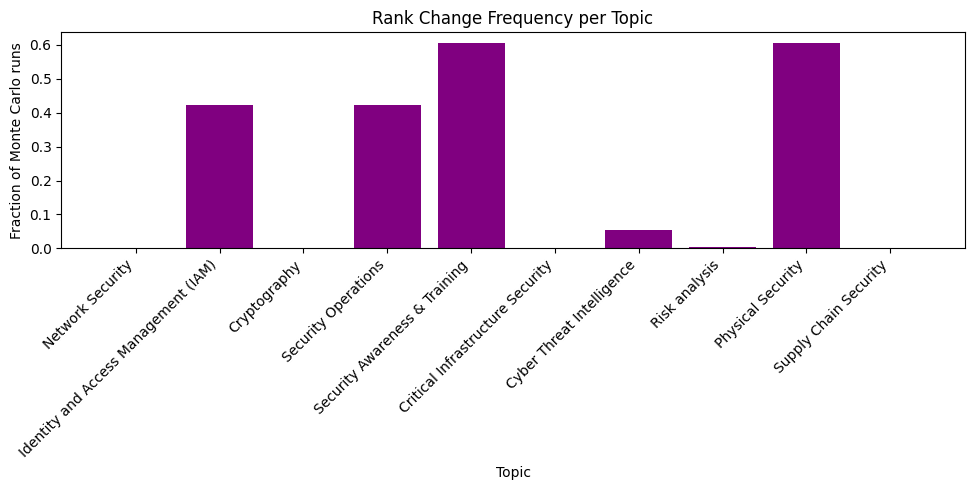

In [97]:
plt.figure(figsize=(10, 5))
plt.bar(
    rank_change_freq.keys(),
    rank_change_freq.values(),
    color="purple"
)
plt.title("Rank Change Frequency per Topic")
plt.ylabel("Fraction of Monte Carlo runs")
plt.xlabel("Topic")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Score Dispersion per Topic

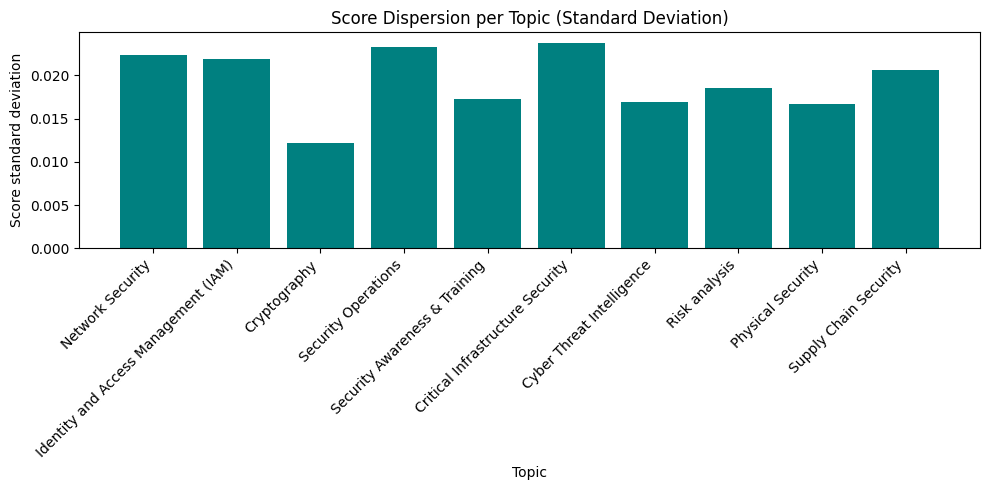

In [98]:
plt.figure(figsize=(10, 5))
plt.bar(
    score_std.keys(),
    score_std.values(),
    color="teal"
)
plt.title("Score Dispersion per Topic (Standard Deviation)")
plt.ylabel("Score standard deviation")
plt.xlabel("Topic")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Stress test plot

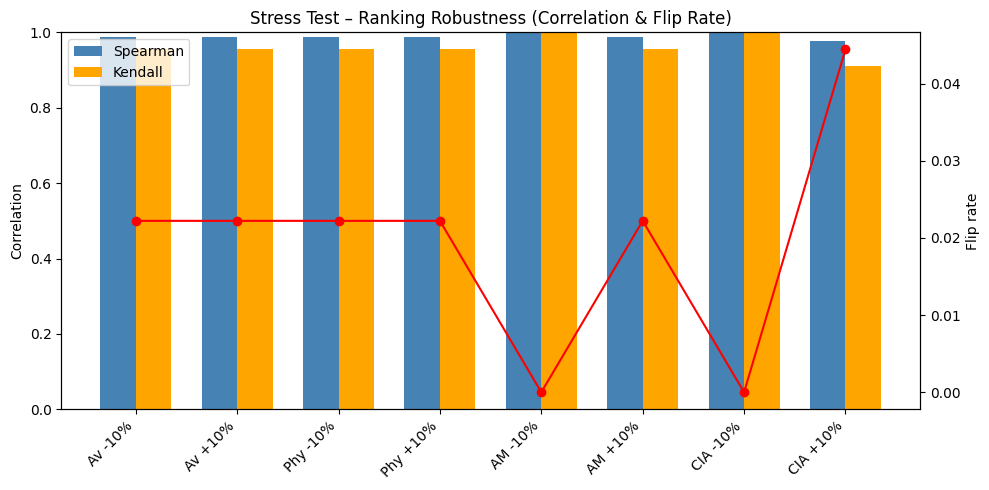

In [99]:
x = range(len(stress_df))

fig, ax1 = plt.subplots(figsize=(10, 5))

# Correlations (bars)
ax1.bar(x, stress_df["Spearman"], width=0.35, label="Spearman", color="steelblue")
ax1.bar(
    [i + 0.35 for i in x],
    stress_df["Kendall"],
    width=0.35,
    label="Kendall",
    color="orange"
)

ax1.set_ylabel("Correlation")
ax1.set_ylim(0, 1)
ax1.set_xticks([i + 0.175 for i in x])
ax1.set_xticklabels(stress_df["Scenario"], rotation=45, ha="right")
ax1.legend(loc="upper left")

# Flip rate (line, secondary axis)
ax2 = ax1.twinx()
ax2.plot(
    [i + 0.175 for i in x],
    stress_df["FlipRate"],
    color="red",
    marker="o",
    label="Flip Rate"
)
ax2.set_ylabel("Flip rate")

# Title
plt.title("Stress Test – Ranking Robustness (Correlation & Flip Rate)")
fig.tight_layout()
plt.show()


In [100]:
# %% [markdown]
# ## Structural limit tests: Alpha → 0, Beta → {0,1}

structural_results = []

for beta_test in [0.0, 1.0]:
    eta_beta = compute_eta_matrix(topic_df, beta_test)
    eta_beta = eta_beta.loc[eta_matrix.index]
    eta_prime_beta = compute_eta_prime(eta_beta, M)
    scores_beta = compute_scores(weights, eta_prime_beta)
    ranks_beta = scores_beta.rank(ascending=False)

    rho, _ = spearmanr(baseline_ranks, ranks_beta)
    tau, _ = kendalltau(baseline_ranks, ranks_beta)

    structural_results.append({
        "Scenario": f"Beta = {beta_test}",
        "Spearman": rho,
        "Kendall": tau
    })

# Alpha → 0 (no interdependency)
eta_prime_alpha0 = compute_eta_prime(eta_matrix, np.eye(M.shape[0]))
scores_alpha0 = compute_scores(weights, eta_prime_alpha0)
ranks_alpha0 = scores_alpha0.rank(ascending=False)

rho, _ = spearmanr(baseline_ranks, ranks_alpha0)
tau, _ = kendalltau(baseline_ranks, ranks_alpha0)

structural_results.append({
    "Scenario": "Alpha = 0",
    "Spearman": rho,
    "Kendall": tau
})

structural_df = pd.DataFrame(structural_results)
structural_df


,Scenario,Spearman,Kendall
0,Beta = 0.0,0.769697,0.644444
1,Beta = 1.0,0.866667,0.777778
2,Alpha = 0,0.951515,0.866667


In [101]:
# %% [markdown]
# ## Objective dominance tests (one objective → 1)

dominance_results = []

for obj in weights.keys():
    dominant_weights = {k: 0.0 for k in weights}
    dominant_weights[obj] = 1.0

    scores_dom = compute_scores(dominant_weights, eta_prime)
    ranks_dom = scores_dom.rank(ascending=False)

    rho, _ = spearmanr(baseline_ranks, ranks_dom)
    tau, _ = kendalltau(baseline_ranks, ranks_dom)

    dominance_results.append({
        "Dominant objective": obj,
        "Spearman": rho,
        "Kendall": tau
    })

dominance_df = pd.DataFrame(dominance_results)
dominance_df


,Dominant objective,Spearman,Kendall
0,Av,0.793939,0.600000
1,Phy,0.490909,0.333333
2,AM,0.393939,0.333333
3,CIA,0.272727,0.111111


In [102]:
# %% [markdown]
# ## Matrix conditioning & numerical stability

cond_M = np.linalg.cond(M)

print("Condition number of M:", cond_M)

if cond_M > 1e6:
    print("⚠️ Warning: M may be ill-conditioned.")
else:
    print("✅ M is well-conditioned.")

# Finite-value check
assert np.isfinite(eta_prime.values).all(), "Non-finite values detected in eta_prime"


Condition number of M: 1.5987713013489493
✅ M is well-conditioned.


In [103]:
# %% [markdown]
# ## Non-uniform uncertainty model (truncated Gaussian)

GAUSS_STD = UNCERTAINTY / 2
spearman_gauss = []
kendall_gauss = []

for _ in range(N_SIM):
    # Gaussian ORI perturbation
    perturbed_weights = {
        k: v * (1 + np.random.normal(0, GAUSS_STD))
        for k, v in weights.items()
    }
    total = sum(perturbed_weights.values())
    perturbed_weights = {k: max(v / total, 0) for k, v in perturbed_weights.items()}

    # Gaussian topic perturbation
    perturbed_topic_df = topic_df.copy()
    for col in ["r_Av","r_Phy","r_AM","r_CIA","u_Av","u_Phy","u_AM","u_CIA","v_j"]:
        perturbed_topic_df[col] *= (1 + np.random.normal(0, GAUSS_STD))
        perturbed_topic_df[col] = perturbed_topic_df[col].clip(0, 1)

    eta_mc = compute_eta_matrix(perturbed_topic_df, BETA)
    eta_mc = eta_mc.loc[eta_matrix.index]
    eta_prime_mc = compute_eta_prime(eta_mc, M)
    scores_mc = compute_scores(perturbed_weights, eta_prime_mc)
    ranks_mc = scores_mc.rank(ascending=False)

    rho, _ = spearmanr(baseline_ranks, ranks_mc)
    tau, _ = kendalltau(baseline_ranks, ranks_mc)

    spearman_gauss.append(rho)
    kendall_gauss.append(tau)

print("Gaussian noise Spearman mean:", np.mean(spearman_gauss))
print("Gaussian noise Kendall mean :", np.mean(kendall_gauss))


Gaussian noise Spearman mean: 0.9872533333333333
Gaussian noise Kendall mean : 0.9544755555555555


In [104]:
# %% [markdown]
# ## Rank displacement metrics (expected deviation)

rank_displacement = {topic: [] for topic in baseline_ranks.index}

for _ in range(N_SIM):
    perturbed_weights = {k: v * (1 + np.random.uniform(-UNCERTAINTY, UNCERTAINTY)) for k, v in weights.items()}
    total = sum(perturbed_weights.values())
    perturbed_weights = {k: v / total for k, v in perturbed_weights.items()}

    perturbed_topic_df = topic_df.copy()
    for col in ["r_Av","r_Phy","r_AM","r_CIA","u_Av","u_Phy","u_AM","u_CIA","v_j"]:
        perturbed_topic_df[col] *= (1 + np.random.uniform(-UNCERTAINTY, UNCERTAINTY))
        perturbed_topic_df[col] = perturbed_topic_df[col].clip(0, 1)

    eta_mc = compute_eta_matrix(perturbed_topic_df, BETA)
    eta_mc = eta_mc.loc[eta_matrix.index]
    eta_prime_mc = compute_eta_prime(eta_mc, M)
    scores_mc = compute_scores(perturbed_weights, eta_prime_mc)
    ranks_mc = scores_mc.rank(ascending=False)

    for topic in baseline_ranks.index:
        rank_displacement[topic].append(
            abs(ranks_mc.loc[topic] - baseline_ranks.loc[topic])
        )

expected_displacement = {
    topic: np.mean(vals)
    for topic, vals in rank_displacement.items()
}

disp_df = pd.DataFrame.from_dict(
    expected_displacement,
    orient="index",
    columns=["Expected rank displacement"]
).sort_values("Expected rank displacement", ascending=False)

disp_df


,Expected rank displacement
Physical Security,0.6685
Security Awareness & Training,0.6119
Identity and Access Management (IAM),0.4249
Security Operations,0.4249
Cyber Threat Intelligence,0.0564
Risk analysis,0.0049
Network Security,0.0001
Cryptography,0.0000
Critical Infrastructure Security,0.0000
Supply Chain Security,0.0000


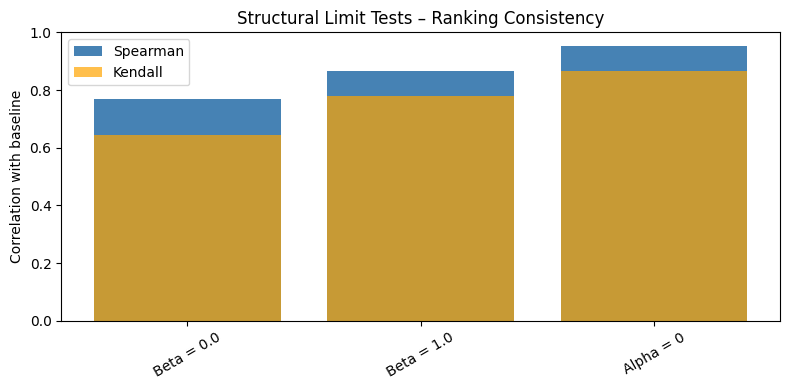

In [105]:
# %% [markdown]
# ## Structural limit tests – correlation comparison

plt.figure(figsize=(8, 4))
plt.bar(
    structural_df["Scenario"],
    structural_df["Spearman"],
    label="Spearman",
    color="steelblue"
)
plt.bar(
    structural_df["Scenario"],
    structural_df["Kendall"],
    label="Kendall",
    color="orange",
    alpha=0.7
)
plt.ylim(0, 1)
plt.ylabel("Correlation with baseline")
plt.title("Structural Limit Tests – Ranking Consistency")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


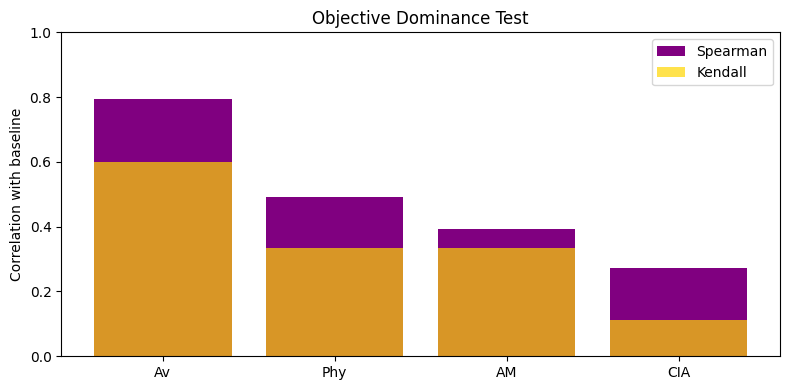

In [106]:
# %% [markdown]
# ## Objective dominance – correlation chart

plt.figure(figsize=(8, 4))
plt.bar(
    dominance_df["Dominant objective"],
    dominance_df["Spearman"],
    label="Spearman",
    color="purple"
)
plt.bar(
    dominance_df["Dominant objective"],
    dominance_df["Kendall"],
    label="Kendall",
    color="gold",
    alpha=0.7
)
plt.ylim(0, 1)
plt.ylabel("Correlation with baseline")
plt.title("Objective Dominance Test")
plt.legend()
plt.tight_layout()
plt.show()


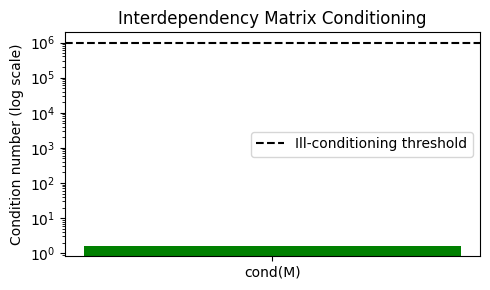

In [107]:
# %% [markdown]
# ## Matrix conditioning diagnostic

plt.figure(figsize=(5, 3))
plt.bar(["cond(M)"], [cond_M], color="red" if cond_M > 1e6 else "green")
plt.axhline(1e6, linestyle="--", color="black", label="Ill-conditioning threshold")
plt.yscale("log")
plt.ylabel("Condition number (log scale)")
plt.title("Interdependency Matrix Conditioning")
plt.legend()
plt.tight_layout()
plt.show()


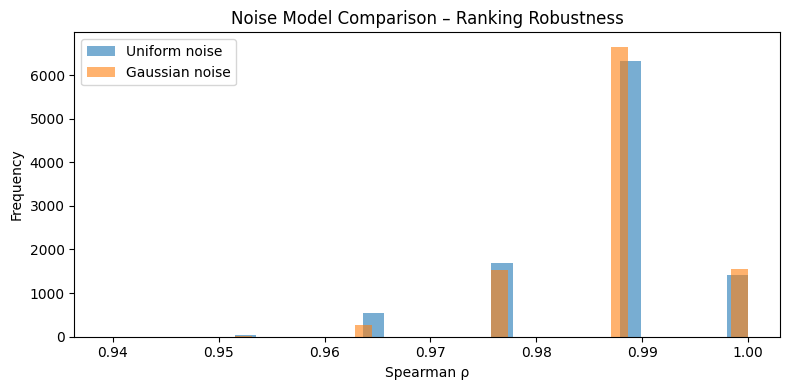

In [108]:
# %% [markdown]
# ## Noise model comparison – Spearman distributions

plt.figure(figsize=(8, 4))
plt.hist(spearman_vals, bins=30, alpha=0.6, label="Uniform noise")
plt.hist(spearman_gauss, bins=30, alpha=0.6, label="Gaussian noise")
plt.xlabel("Spearman ρ")
plt.ylabel("Frequency")
plt.title("Noise Model Comparison – Ranking Robustness")
plt.legend()
plt.tight_layout()
plt.show()


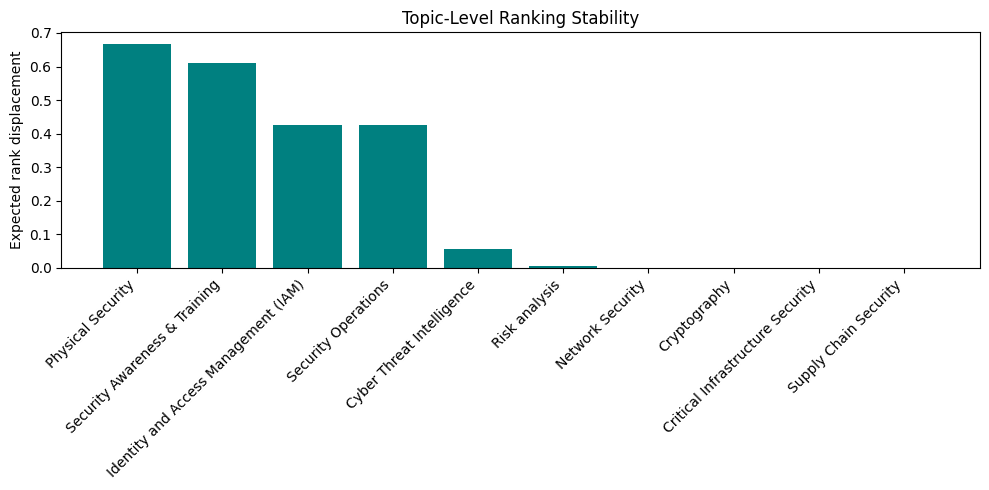

In [109]:
# %% [markdown]
# ## Expected rank displacement per topic

plt.figure(figsize=(10, 5))
plt.bar(
    disp_df.index,
    disp_df["Expected rank displacement"],
    color="teal"
)
plt.ylabel("Expected rank displacement")
plt.title("Topic-Level Ranking Stability")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


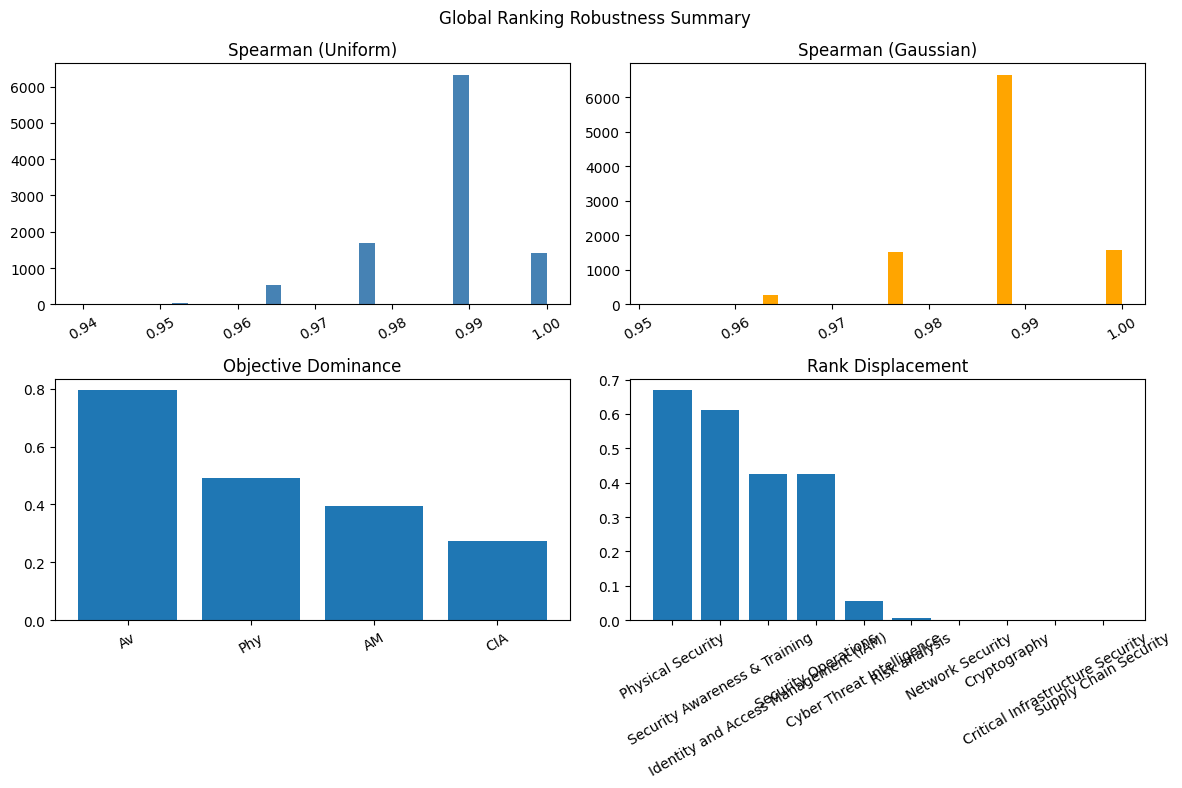

In [110]:
# %% [markdown]
# ## Global robustness dashboard

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].hist(spearman_vals, bins=30, color="steelblue")
axs[0, 0].set_title("Spearman (Uniform)")

axs[0, 1].hist(spearman_gauss, bins=30, color="orange")
axs[0, 1].set_title("Spearman (Gaussian)")

axs[1, 0].bar(dominance_df["Dominant objective"], dominance_df["Spearman"])
axs[1, 0].set_title("Objective Dominance")

axs[1, 1].bar(disp_df.index, disp_df["Expected rank displacement"])
axs[1, 1].set_title("Rank Displacement")

for ax in axs.flat:
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Global Ranking Robustness Summary")
plt.tight_layout()
plt.show()